## 1.1 Needed Packages

In [2]:
#Importing pakages

#Data Processing
import numpy as np
import pandas as pd
import math

#Visualization
import seaborn as sns
import matplotlib.pyplot as plt

#Data processing modules
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

#Machine Learing Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC


## 1.2 Data Loading

In [3]:
data = 'ESS.csv'
df = pd.read_csv(data)
df_clean = df.drop(['name','essround','edition','proddate','idno','dweight','anweight','prob', 'stratum','psu','pspwght','pweight'], axis=1)
# Define missing value codes for each variable
missing_map = {
    'bctprd': [7, 8, 9],
    'gndr': [9],
    'agea': [999],
    'eduyrs': [77, 88, 99],
    'netusoft': [7,8,9],
    'nwspol': [7777,8888,9999]
}

# Variables with 66, 77, 88, 99 as missing
value_vars = ['ipcrtiva', 'impricha', 'ipeqopta', 'ipshabta', 'impsafea', 'impdiffa',
              'ipfrulea', 'ipudrsta', 'ipmodsta', 'ipgdtima', 'impfreea', 'iphlppla',
              'ipsucesa', 'ipstrgva', 'ipadvnta', 'ipbhprpa', 'iprspota', 'iplylfra',
              'impenva', 'imptrada', 'impfuna']

for var in value_vars:
    missing_map[var] = [66, 77, 88, 99]

# Replace defined missing codes with NaN
for col, codes in missing_map.items():
    df_clean[col] = df_clean[col].replace(codes, np.nan)

df_clean.rename(columns={'agea': 'age', 'nwspol':'news', 'eduyrs': 'education_years', 'gndr': 'gender', 'cntry':'country', 'bctprd':'boycott', 'netusoft': 'internet'}, inplace=True)

df_clean['boycott'] = df_clean['boycott'].replace(2, 0)
df_clean = df_clean.dropna(subset=['boycott'])


## 1.3 EDA

In [4]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49806 entries, 0 to 50115
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          49806 non-null  object 
 1   news             49090 non-null  float64
 2   internet         49756 non-null  float64
 3   boycott          49806 non-null  float64
 4   gender           49806 non-null  int64  
 5   age              49429 non-null  float64
 6   education_years  48943 non-null  float64
 7   ipcrtiva         48898 non-null  float64
 8   impricha         48991 non-null  float64
 9   ipeqopta         48945 non-null  float64
 10  ipshabta         48918 non-null  float64
 11  impsafea         49032 non-null  float64
 12  impdiffa         48959 non-null  float64
 13  ipfrulea         48625 non-null  float64
 14  ipudrsta         48845 non-null  float64
 15  ipmodsta         48919 non-null  float64
 16  ipgdtima         48965 non-null  float64
 17  impfreea         

In [5]:
df_clean.describe()

,news,internet,boycott,gender,age,education_years,ipcrtiva,impricha,ipeqopta,ipshabta,...,iphlppla,ipsucesa,ipstrgva,ipadvnta,ipbhprpa,iprspota,iplylfra,impenva,imptrada,impfuna
count,49090.000000,49756.000000,49806.000000,49806.000000,49429.000000,48943.000000,48898.000000,48991.000000,48945.000000,48918.000000,...,49017.000000,48847.000000,48651.000000,48929.000000,48857.000000,48778.000000,48994.000000,48983.000000,48967.000000,48953.000000
mean,97.757547,4.199875,0.185259,1.539112,51.606425,13.248554,2.621089,4.071360,2.048258,3.225255,...,2.192872,3.164903,2.242667,3.813730,2.635405,3.166756,1.970935,2.173264,2.709274,2.959962
std,159.101565,1.418989,0.388511,0.498473,18.665848,4.016341,1.290143,1.360125,1.075486,1.411399,...,1.021043,1.377196,1.166905,1.455888,1.249533,1.387369,0.978976,1.059117,1.364465,1.332657
min,0.000000,1.000000,0.000000,1.000000,15.000000,0.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,30.000000,4.000000,0.000000,1.000000,37.000000,11.000000,2.000000,3.000000,1.000000,2.000000,...,1.000000,2.000000,1.000000,3.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000
50%,60.000000,5.000000,0.000000,2.000000,52.000000,13.000000,2.000000,4.000000,2.000000,3.000000,...,2.000000,3.000000,2.000000,4.000000,2.000000,3.000000,2.000000,2.000000,2.000000,3.000000
75%,120.000000,5.000000,0.000000,2.000000,67.000000,16.000000,3.000000,5.000000,3.000000,4.000000,...,3.000000,4.000000,3.000000,5.000000,3.000000,4.000000,2.000000,3.000000,4.000000,4.000000
max,1440.000000,5.000000,1.000000,2.000000,90.000000,69.000000,6.000000,6.000000,6.000000,6.000000,...,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000


In [6]:
df_clean.head(5)

,country,news,internet,boycott,gender,age,education_years,ipcrtiva,impricha,ipeqopta,...,iphlppla,ipsucesa,ipstrgva,ipadvnta,ipbhprpa,iprspota,iplylfra,impenva,imptrada,impfuna
0,AT,90.0,5.0,0.0,1,65.0,12.0,3.0,5.0,2.0,...,2.0,3.0,2.0,5.0,2.0,2.0,2.0,2.0,3.0,3.0
1,AT,90.0,5.0,1.0,2,21.0,14.0,2.0,4.0,2.0,...,1.0,4.0,2.0,4.0,2.0,4.0,1.0,1.0,4.0,2.0
2,AT,30.0,5.0,1.0,2,53.0,16.0,1.0,4.0,1.0,...,1.0,3.0,2.0,4.0,3.0,3.0,1.0,1.0,3.0,2.0
3,AT,15.0,1.0,0.0,2,78.0,14.0,3.0,4.0,2.0,...,2.0,3.0,3.0,4.0,3.0,3.0,2.0,2.0,2.0,3.0
4,AT,60.0,5.0,0.0,1,64.0,12.0,3.0,4.0,2.0,...,2.0,2.0,2.0,4.0,2.0,2.0,2.0,2.0,2.0,2.0


In [7]:

df_clean[['gender', 'boycott']] = df_clean[['gender', 'boycott']].astype('object')
numerical_cols = df_clean.select_dtypes(include = 'float64').columns
categorical_cols = df_clean.select_dtypes(include = 'object').columns

print(numerical_cols.values)
print(categorical_cols.values)



['news' 'internet' 'age' 'education_years' 'ipcrtiva' 'impricha'
 'ipeqopta' 'ipshabta' 'impsafea' 'impdiffa' 'ipfrulea' 'ipudrsta'
 'ipmodsta' 'ipgdtima' 'impfreea' 'iphlppla' 'ipsucesa' 'ipstrgva'
 'ipadvnta' 'ipbhprpa' 'iprspota' 'iplylfra' 'impenva' 'imptrada'
 'impfuna']
['country' 'boycott' 'gender']


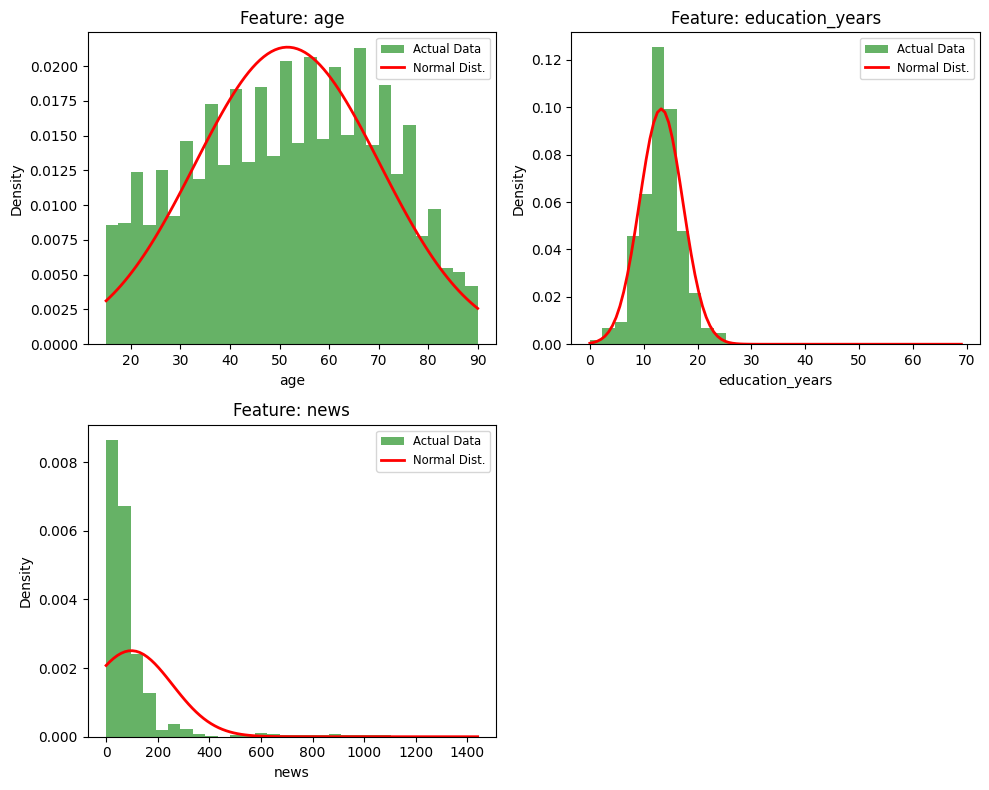

In [8]:

# 1. Define  features 
selected_cols = ['age', 'education_years', 'news'] 
# If you want to run all numerical columns, use: selected_cols = numerical_cols
X = df_clean.drop('boycott', axis=1)
y = df_clean['boycott'].astype(int)

# 2. Calculate dynamic grid dimensions
n_features = len(selected_cols)
n_cols = 2  # You can change this to 3 or 4 for more columns
n_rows = math.ceil(n_features / n_cols)

# 3. Initialize the figure
fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))

# Ensure ax is an array even if there is only 1 plot
if n_features > 1:
    ax = ax.flatten()
else:
    ax = [ax]

# 4. Loop through each feature to create the plots
for c, column in enumerate(selected_cols):
    # Calculate mean (mu) and standard deviation (sigma)
    mu, sigma = X[column].mean(), X[column].std()
    
    # Plot Histogram: density=True normalizes the y-axis to total 1 (Density)
    # Using 20-30 bins is standard for seeing the distribution shape
    count, bins_edges, ignored = ax[c].hist(X[column], bins=30, density=True, 
                                            alpha=0.6, color='g', label='Actual Data')

    # Generate smooth X-values for the Normal Distribution curve
    # This prevents the "jagged" red line seen when using histogram bins
    x_smooth = np.linspace(X[column].min(), X[column].max(), 100)
    
    # Calculate the Probability Density Function (PDF)
    pdf = 1 / (sigma * np.sqrt(2 * np.pi)) * np.exp(-(x_smooth - mu) ** 2 / (2 * sigma ** 2))
    
    # Plot the Normal Distribution curve
    ax[c].plot(x_smooth, pdf, linewidth=2, color='r', label='Normal Dist.')

    # Formatting
    ax[c].set_title(f'Feature: {column}')
    ax[c].set_xlabel(column)
    ax[c].set_ylabel('Density')
    ax[c].legend(fontsize='small')

# 5. Hide unused axes (if n_features < total grid slots)
for i in range(n_features, len(ax)):
    ax[i].axis('off')

# 6. Final layout and save
plt.tight_layout()
plt.show()

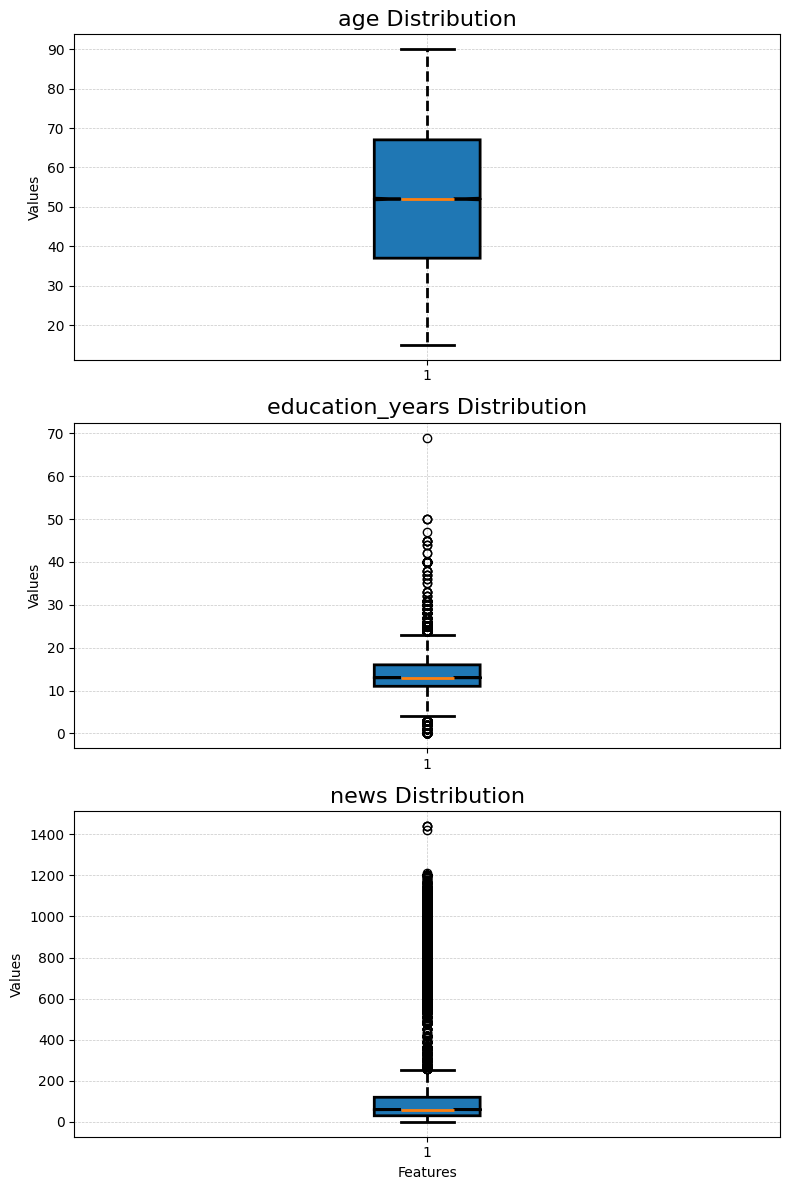

In [9]:
box_cols = ['age', 'education_years', 'news']

# Convert to numeric + drop missing values
box_data = X[box_cols].apply(pd.to_numeric, errors='coerce').dropna()

fig, axes = plt.subplots(3, 1, figsize=(8, 12))

boxprops = dict(linestyle='-', linewidth=2)
medianprops = dict(linestyle='-', linewidth=2)
whiskerprops = dict(linestyle='--', linewidth=2)
capprops = dict(linestyle='-', linewidth=2)

for i, col in enumerate(box_cols):
    axes[i].boxplot(
        box_data[col].values,
        notch=True,
        patch_artist=True,
        boxprops=boxprops,
        medianprops=medianprops,
        whiskerprops=whiskerprops,
        capprops=capprops
    )

    axes[i].set_title(f'{col} Distribution', fontsize=16)
    axes[i].set_ylabel('Values')
    axes[i].grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

axes[-1].set_xlabel('Features')

plt.tight_layout()
plt.show()
#plt.savefig('Age_Eduyrs_boxplot.pdf', dpi=300)



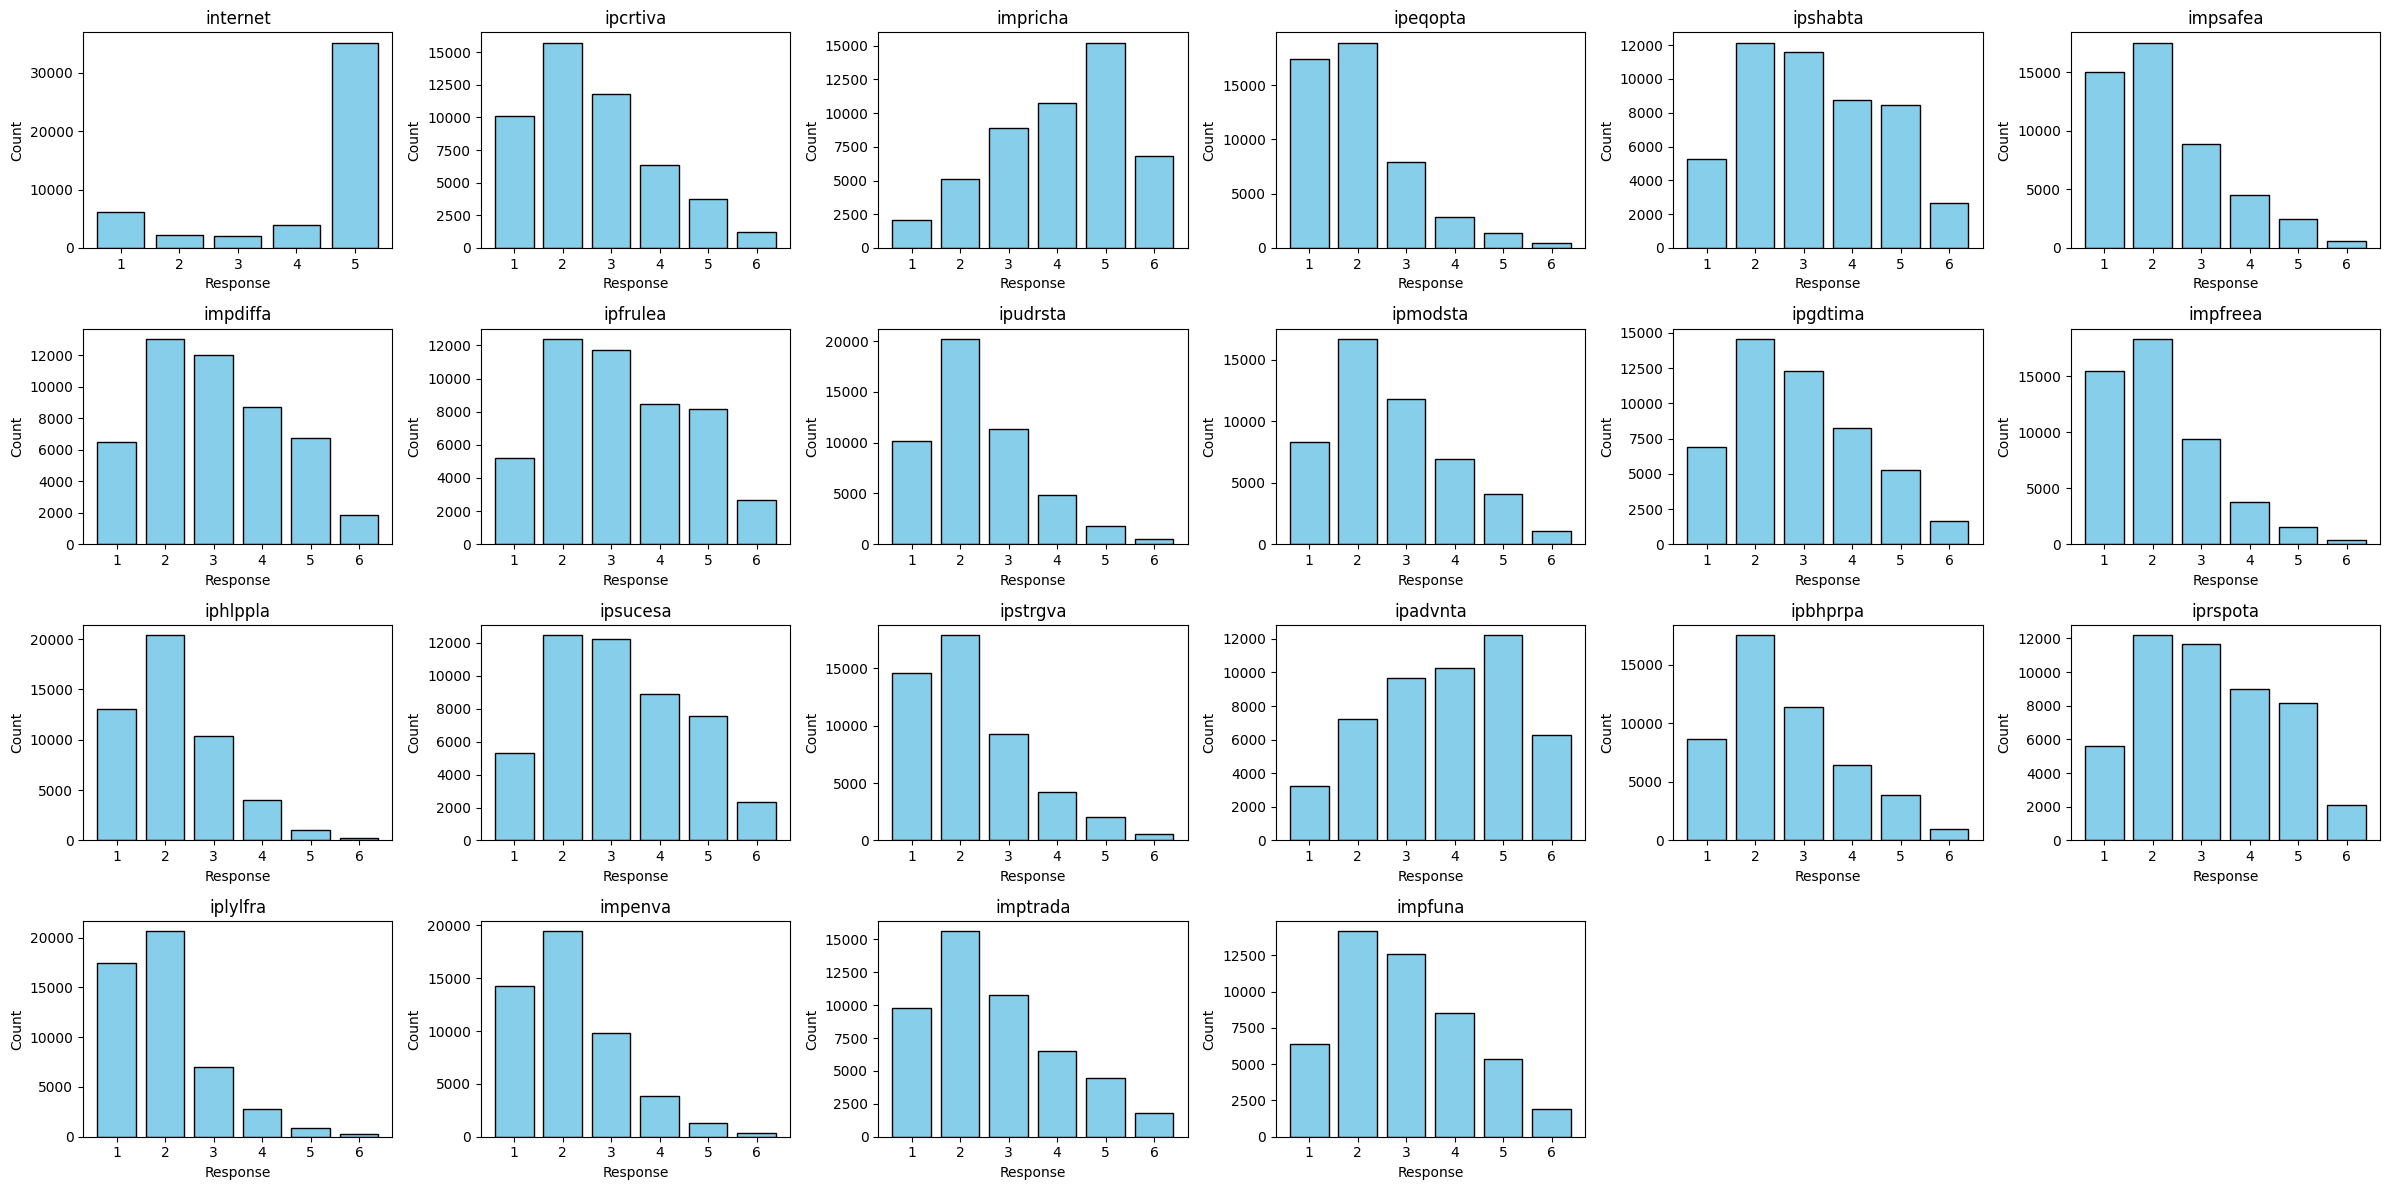

In [10]:



likert_cols = [c for c in numerical_cols if c not in ['age', 'education_years', 'news']]

n_cols = 6
n_rows = int(np.ceil(len(likert_cols) / n_cols))

fig, ax = plt.subplots(n_rows, n_cols, figsize=(24, 12))
ax = ax.flatten()

for i, column in enumerate(likert_cols):
    counts = X[column].value_counts().sort_index()
    
    # Plot bar chart
    ax[i].bar(counts.index, counts.values, color='skyblue', edgecolor='black')
    
    # Titles and labels
    ax[i].set_title(column)
    ax[i].set_xlabel('Response')
    ax[i].set_ylabel('Count')
    
    # Dynamically set x-ticks based on actual responses
    ax[i].set_xticks(counts.index)
    
# Delete any extra empty axes
for j in range(i + 1, len(ax)):
    fig.delaxes(ax[j])

plt.tight_layout()
plt.show()
# Optional: save figure
# plt.savefig('Likert_item_counts.pdf', dpi=300)

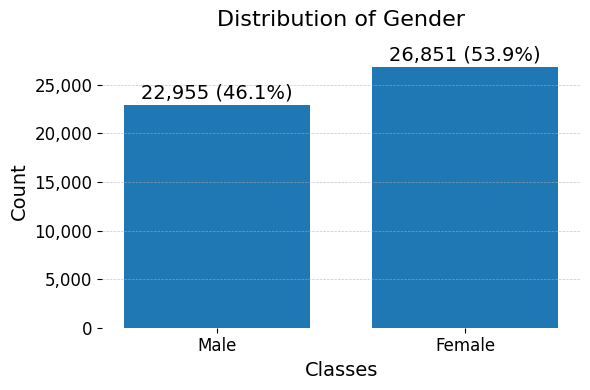

In [11]:
# Count samples in each class (bctprd = 1 or 2)
class_counts = [
    np.sum(df_clean['gender'] == 1),
    np.sum(df_clean['gender'] == 2)
]

class_labels = ['Male', 'Female']

# Calculate percentages
total = sum(class_counts)
class_percents = [(count / total) * 100 for count in class_counts]

# Bar Plot
plt.figure(figsize=(6, 4))
bars = plt.bar(class_labels, class_counts, width=0.75)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7, axis='y')

# Title and labels
plt.title('Distribution of Gender', fontsize=16, pad=20)  # space above bars
plt.xlabel('Classes', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add value labels above the bars with count and percentage
for bar, percent in zip(bars, class_percents):
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + max(class_counts)*0.01,  # slightly above the bar
        f"{int(yval):,} ({percent:.1f}%)",  # count with thousands separator and %
        ha='center',
        va='bottom',
        fontsize=14
    )

# Format y-axis with thousands separator
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Remove spines
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.tight_layout()
#plt.savefig('gender_class_dist.pdf', dpi=300)
plt.show()


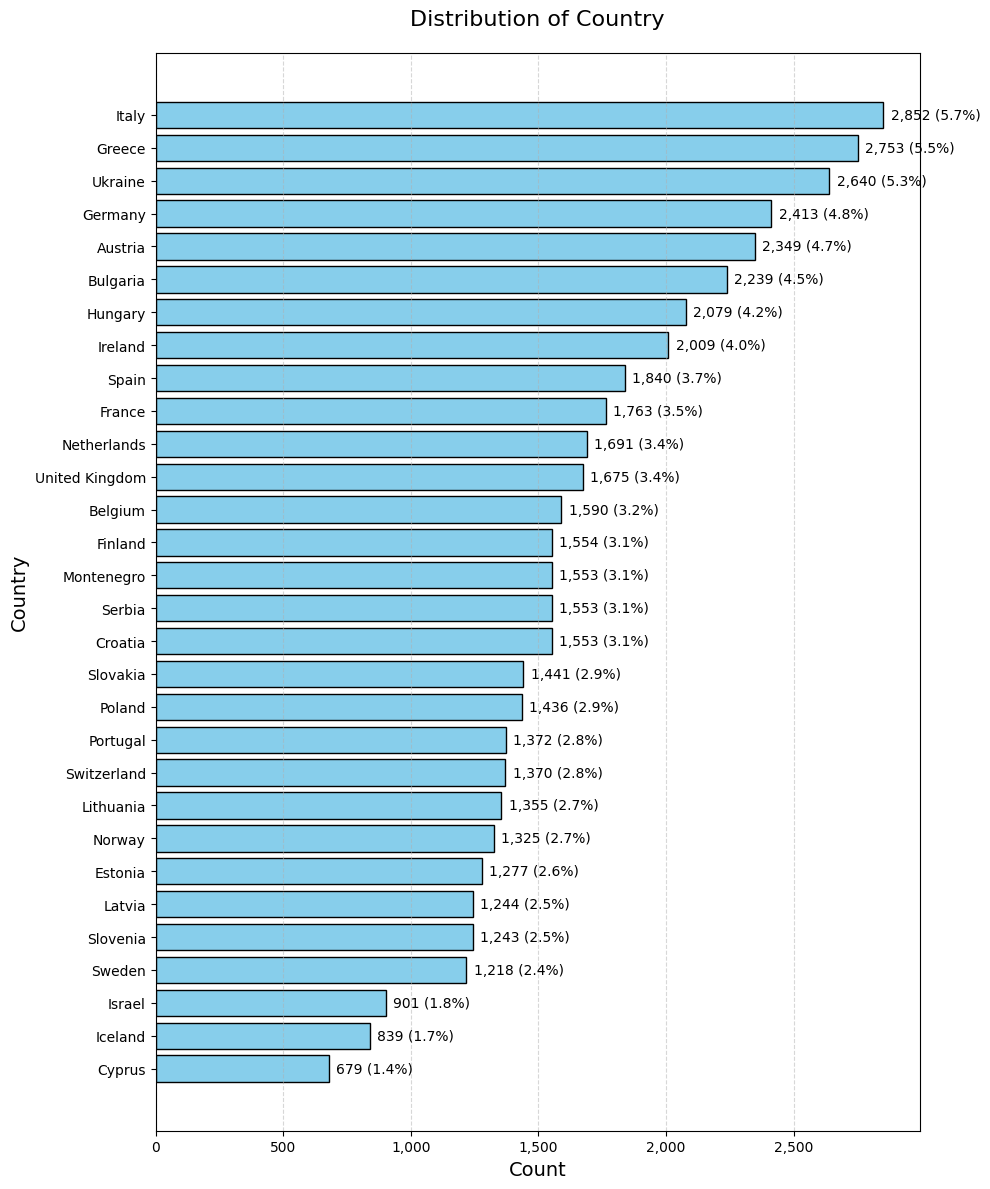

In [12]:


# List of country codes and labels
countries = [
    'AT','BE','BG','CH','CY','DE','EE','ES','FI','FR','GB','GR','HR',
    'HU','IE','IS','IL','IT','LT','LV','ME','NL','NO','PL','PT','RS',
    'SE','SI','SK','UA'
]

country_labels = [
    'Austria','Belgium','Bulgaria','Switzerland','Cyprus','Germany',
    'Estonia','Spain','Finland','France','United Kingdom','Greece','Croatia','Hungary',
    'Ireland','Iceland','Israel','Italy','Lithuania','Latvia','Montenegro','Netherlands',
    'Norway','Poland','Portugal','Serbia',
    'Sweden','Slovenia','Slovakia','Ukraine'
]

# Compute counts
class_counts = [np.sum(df_clean['country'] == c) for c in countries]
total = sum(class_counts)
class_percents = [(count / total) * 100 for count in class_counts]

# Sort from lowest to highest
sorted_idx = np.argsort(class_counts)
sorted_counts = [class_counts[i] for i in sorted_idx]
sorted_labels = [country_labels[i] for i in sorted_idx]
sorted_percents = [class_percents[i] for i in sorted_idx]

# Horizontal bar plot
plt.figure(figsize=(10, 12))
bars = plt.barh(sorted_labels, sorted_counts, color='skyblue', edgecolor='black')

plt.xlabel('Count', fontsize=14)
plt.ylabel('Country', fontsize=14)
plt.title('Distribution of Country', fontsize=16, pad=20)
plt.grid(True, axis='x', linestyle='--', alpha=0.5)

# Add value labels with count and percentage
for bar, percent in zip(bars, sorted_percents):
    width = bar.get_width()
    plt.text(
        width + max(sorted_counts)*0.01,
        bar.get_y() + bar.get_height()/2,
        f"{int(width):,} ({percent:.1f}%)",
        va='center',
        fontsize=10
    )

# Format x-axis with thousands separator
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
#plt.savefig('country_class_dist_horizontal.pdf', dpi=300)
plt.show()


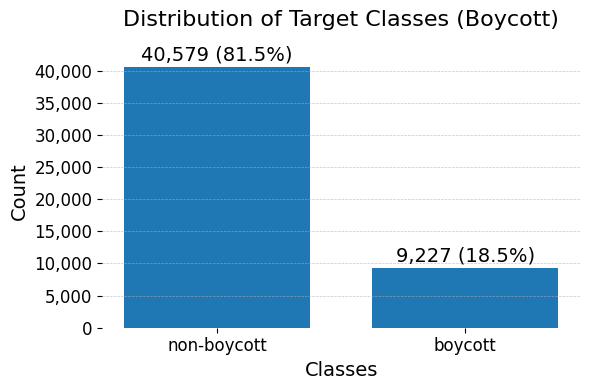

In [13]:
# Count samples in each class (bctprd = 1 or 2)
class_counts = [
    np.sum(df_clean['boycott'] == 0),
    np.sum(df_clean['boycott'] == 1)
]

class_labels = ['non-boycott', 'boycott']

# Calculate percentages
total = sum(class_counts)
class_percents = [(count / total) * 100 for count in class_counts]

# Bar Plot
plt.figure(figsize=(6, 4))
bars = plt.bar(class_labels, class_counts, width=0.75)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7, axis='y')

# Title and labels
plt.title('Distribution of Target Classes (Boycott)', fontsize=16, pad=20)  # space above bars
plt.xlabel('Classes', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add value labels above the bars with count and percentage
for bar, percent in zip(bars, class_percents):
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + max(class_counts)*0.01,  # slightly above the bar
        f"{int(yval):,} ({percent:.1f}%)",  # count with thousands separator and %
        ha='center',
        va='bottom',
        fontsize=14
    )

# Format y-axis with thousands separator
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Remove spines
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.tight_layout()
#plt.savefig('bctprd_class_dist.pdf', dpi=300)
plt.show()


In [14]:
pip install missingno

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<Figure size 2000x600 with 0 Axes>

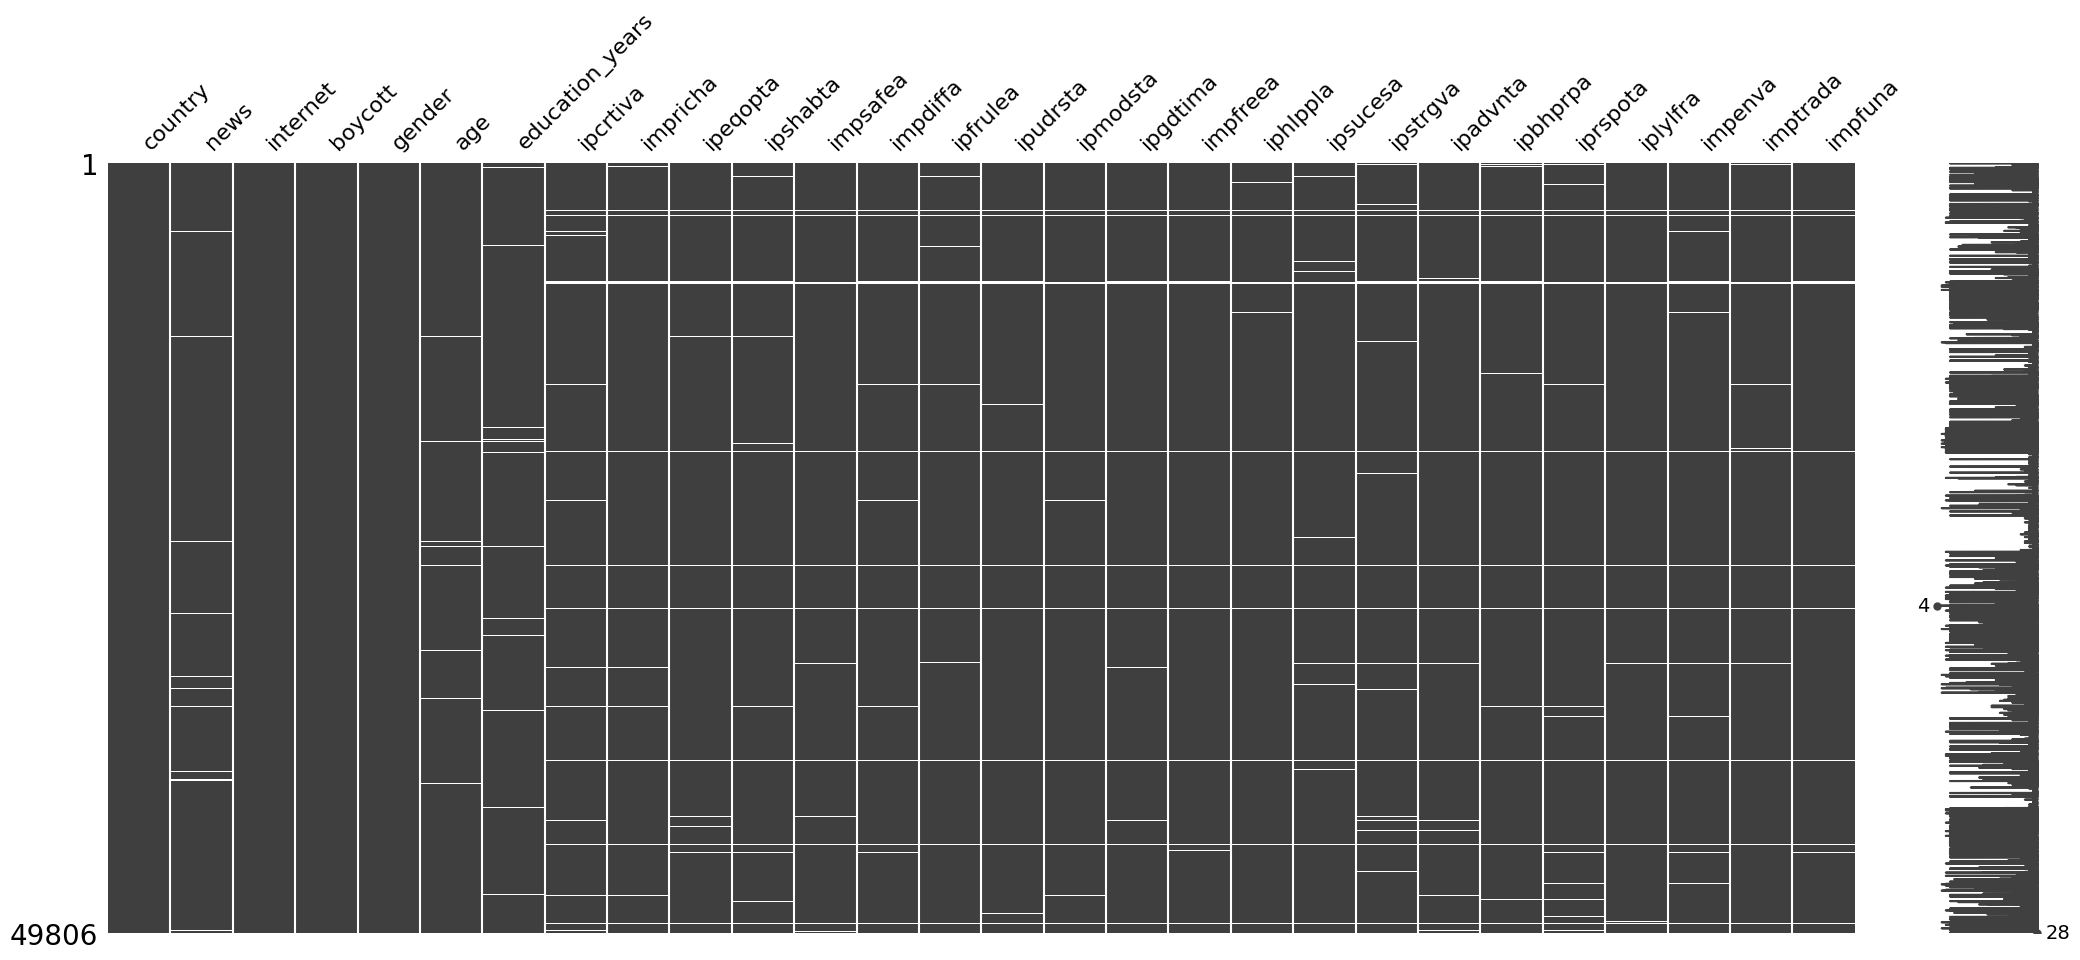

<Figure size 1200x1000 with 0 Axes>

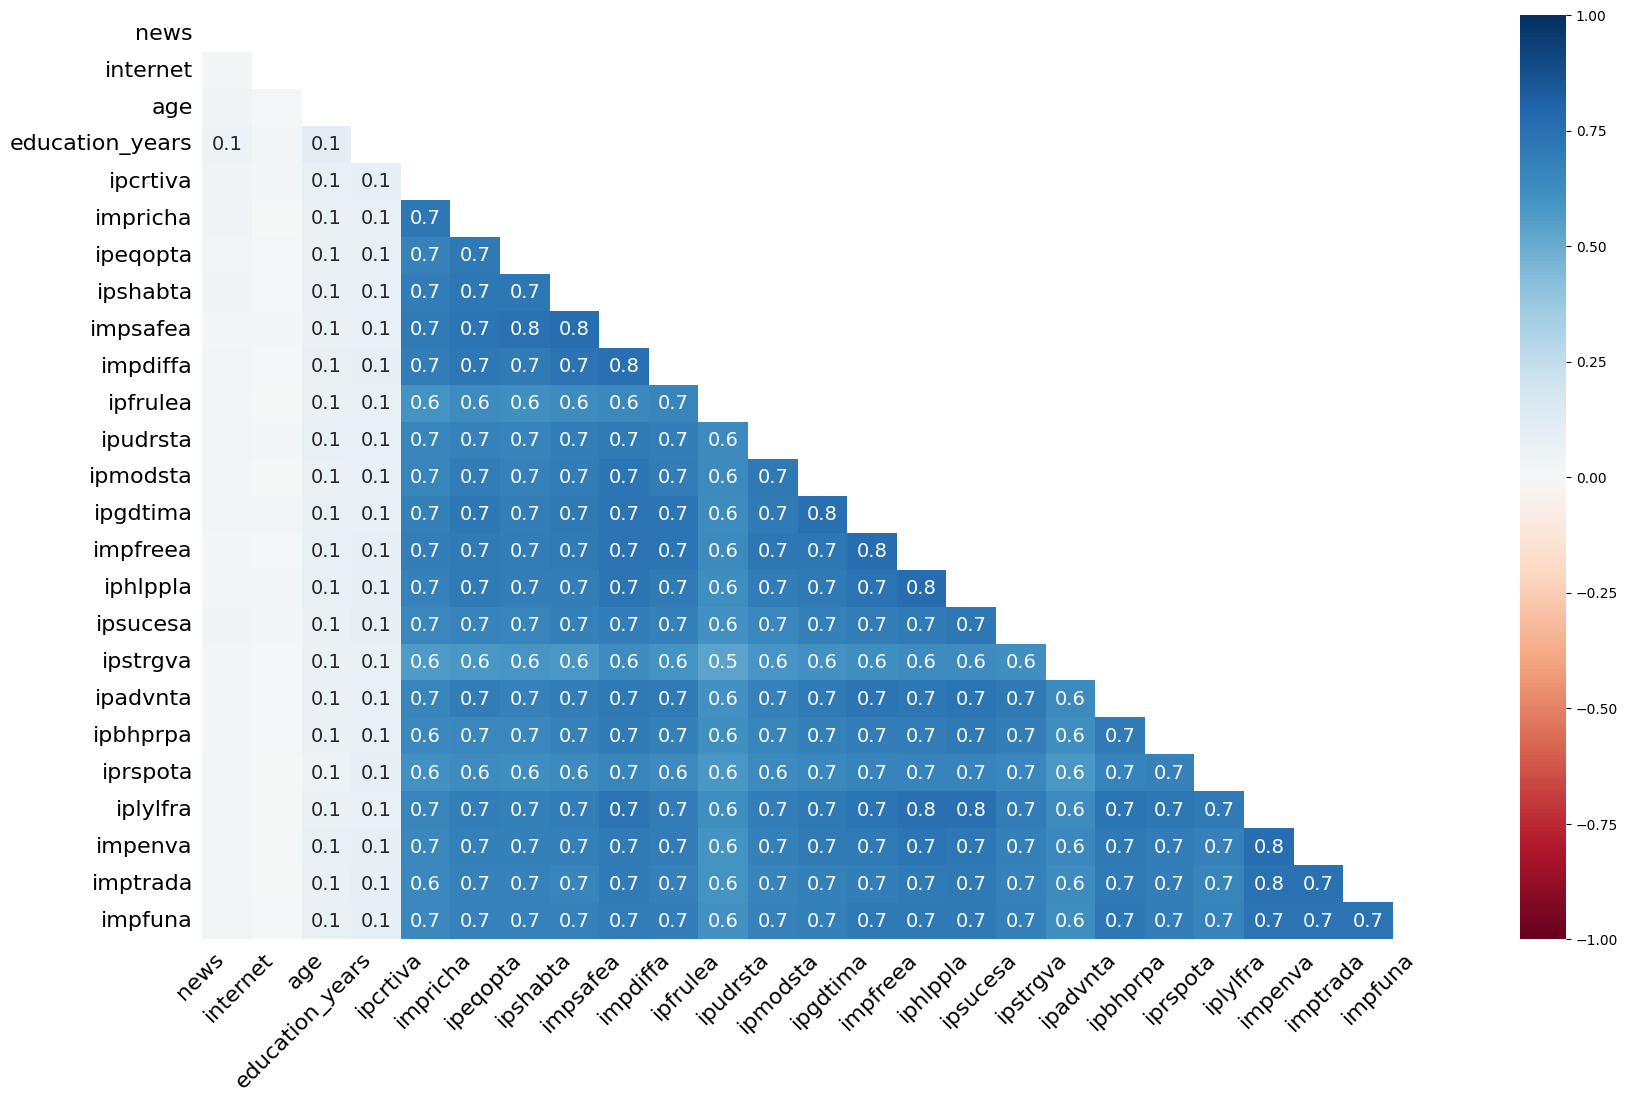

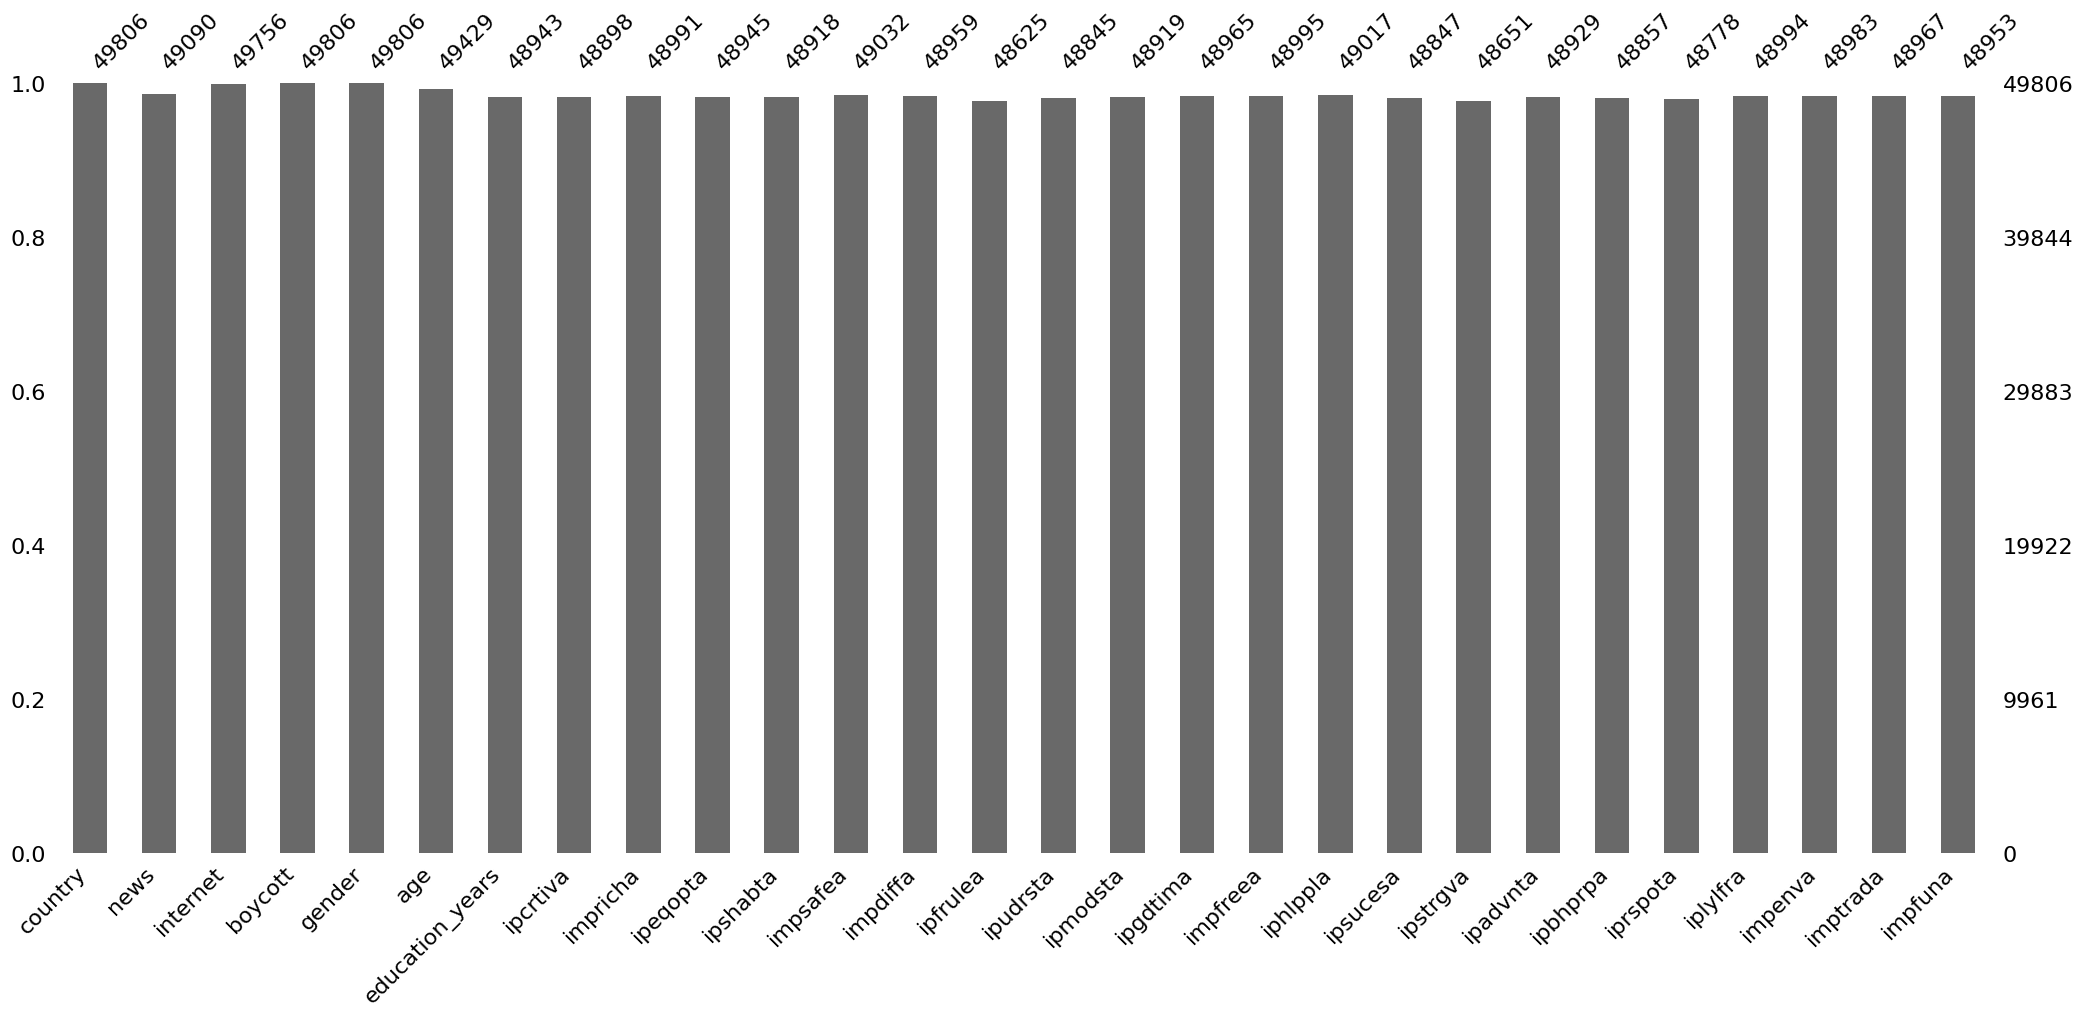

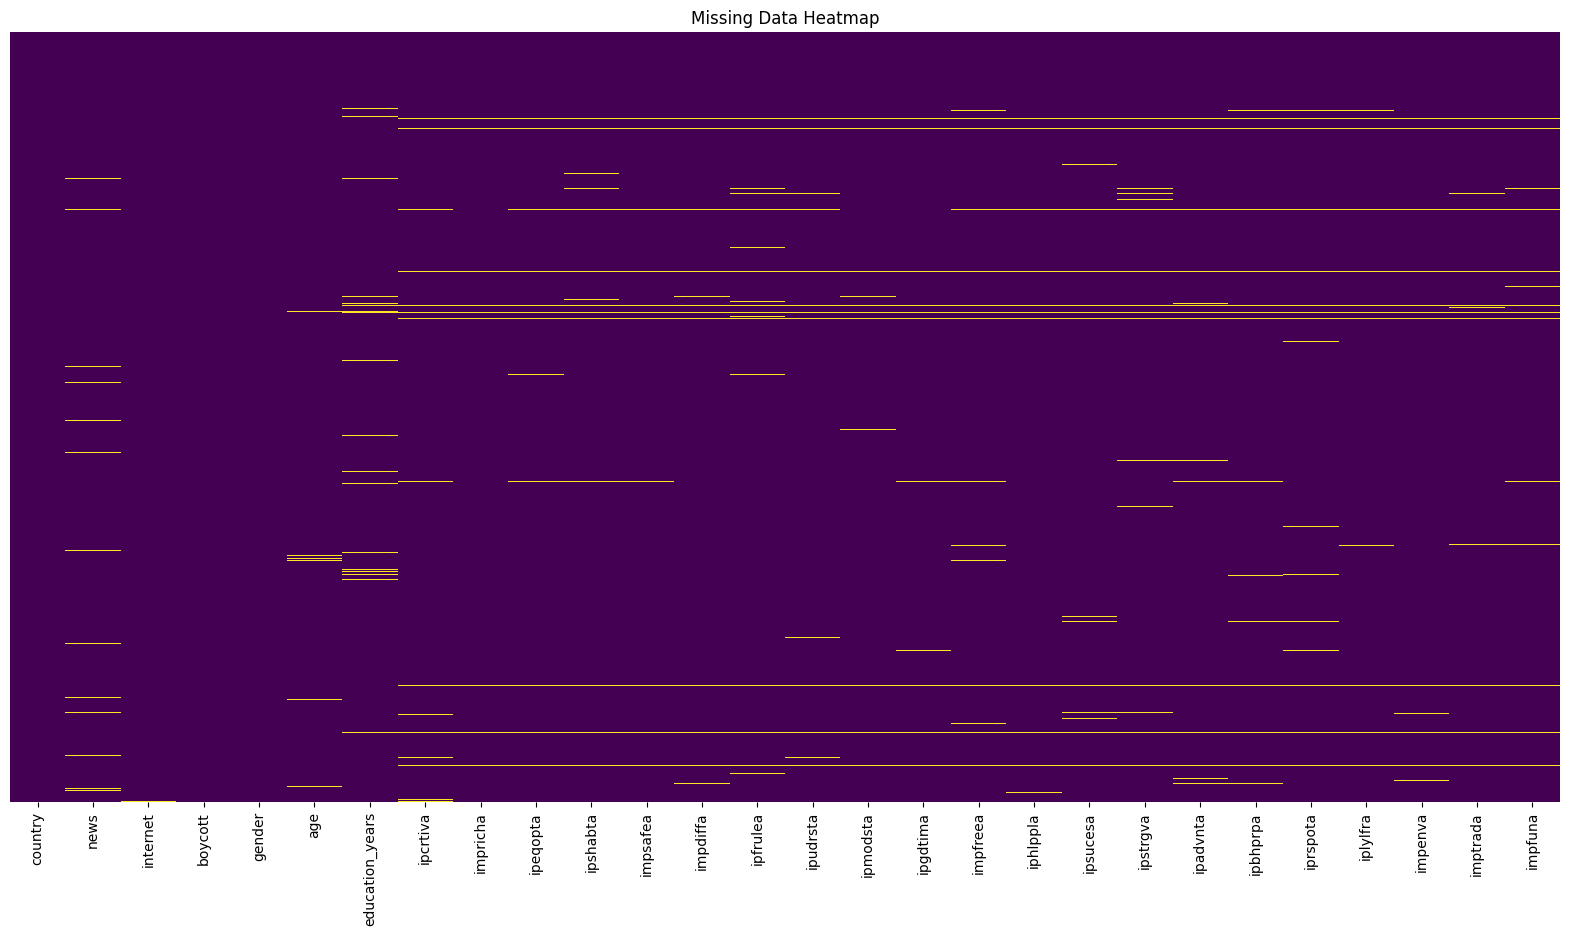

Missing values (%) per column:
ipfrulea           2.371200
ipstrgva           2.318998
iprspota           2.064008
ipudrsta           1.929486
ipsucesa           1.925471
ipbhprpa           1.905393
ipcrtiva           1.823074
ipshabta           1.782918
ipmodsta           1.780910
ipadvnta           1.760832
education_years    1.732723
ipeqopta           1.728707
impfuna            1.712645
impdiffa           1.700598
ipgdtima           1.688552
imptrada           1.684536
impenva            1.652411
impricha           1.636349
iplylfra           1.630326
impfreea           1.628318
iphlppla           1.584146
impsafea           1.554030
news               1.437578
age                0.756937
internet           0.100390
gender             0.000000
country            0.000000
boycott            0.000000
dtype: float64


In [15]:
#missing data pattern
import missingno as msno

# 8a. Missing data matrix
plt.figure(figsize=(20,6))
msno.matrix(df_clean)
plt.show()

# 8b. Missing data heatmap (shows correlation of missingness)
plt.figure(figsize=(12,10))
msno.heatmap(df_clean)
plt.show()

# 8c. Missing data bar chart (count per column)
plt.figure(figsize=(16,6))
msno.bar(df_clean)
plt.show()

# 8d. Optional: seaborn heatmap for full matrix view
plt.figure(figsize=(20,10))
sns.heatmap(df_clean.isna(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

# 9️⃣ OPTIONAL: check missing percentage numerically
missing_percent = df_clean.isna().mean() * 100
missing_percent = missing_percent.sort_values(ascending=False)
print("Missing values (%) per column:")
print(missing_percent)




## 1.4 Preprocessing

In [16]:
#remove outlier
data = df_clean['news']

Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

outlier_percentage = (
    ((data < (Q1 - 1.5*IQR)) | (data > (Q3 + 1.5*IQR))).sum()
    / len(data) * 100
)

print(outlier_percentage)


#calculate 99% percentile
upper_99 = df_clean['news'].quantile(0.99)
print("99th percentile (upper limit):", upper_99)

# remove outliers
df_clean = df_clean[df_clean['news'] <= upper_99]

# sense check max
max_value_after_clean = df_clean['news'].max()
remaining_samples = df_clean.shape[0]

print("Max value after removing extreme values:", max_value_after_clean)
print("Number of remaining samples:", remaining_samples)
print(outlier_percentage)

5.854716299241056
99th percentile (upper limit): 941.3300000000017
Max value after removing extreme values: 941.0
Number of remaining samples: 48599
5.854716299241056


In [17]:
before_rows = df_clean.shape[0]

# delete rows over 40% missing values
threshold = int(df_clean.shape[1] * 0.6)
df_clean = df_clean.dropna(thresh=threshold)

after_rows = df_clean.shape[0]
print("Rows before removal:", before_rows)
print("Rows after removal:", after_rows)
print("Rows removed:", before_rows - after_rows)

Rows before removal: 48599
Rows after removal: 48020
Rows removed: 579


In [18]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48020 entries, 0 to 50115
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          48020 non-null  object 
 1   news             48020 non-null  float64
 2   internet         47977 non-null  float64
 3   boycott          48020 non-null  object 
 4   gender           48020 non-null  object 
 5   age              47701 non-null  float64
 6   education_years  47292 non-null  float64
 7   ipcrtiva         47703 non-null  float64
 8   impricha         47787 non-null  float64
 9   ipeqopta         47739 non-null  float64
 10  ipshabta         47728 non-null  float64
 11  impsafea         47829 non-null  float64
 12  impdiffa         47762 non-null  float64
 13  ipfrulea         47453 non-null  float64
 14  ipudrsta         47670 non-null  float64
 15  ipmodsta         47745 non-null  float64
 16  ipgdtima         47789 non-null  float64
 17  impfreea         

In [26]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_recall_curve, auc, precision_score, recall_score

from sklearn.impute import SimpleImputer   # ✅ changed

# -----------------------------
# Define target and input
# -----------------------------
X = df_clean.drop('boycott', axis=1)
y = df_clean['boycott'].astype(int)

# -----------------------------
# Nested CV with metrics
# -----------------------------
def nested_cv_with_metrics(X, y, use_class_weight=False):

    random_state = 42
    outer_splits = 5
    inner_splits = 5

    numerical_cols = X.select_dtypes(include=['float64']).columns
    categorical_cols = X.select_dtypes(include=['object']).columns

    # -----------------------------
    # Preprocessor (CHANGED HERE)
    # -----------------------------
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),  # ✅ changed
                ('scaler', StandardScaler())
            ]), numerical_cols),
            ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
        ]
    )

    model = LogisticRegression(
        max_iter=2000,
        solver='liblinear',
        random_state=random_state,
        class_weight='balanced' if use_class_weight else None
    )

    param_grid = {"model__C": [0.1, 1.0, 10.0]}

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    outer_cv = StratifiedKFold(n_splits=outer_splits, shuffle=True, random_state=random_state)
    inner_cv = StratifiedKFold(n_splits=inner_splits, shuffle=True, random_state=random_state)

    outer_f1, outer_pr_auc, outer_precision, outer_recall = [], [], [], []
    inner_f1_all, inner_pr_auc_all = [], []
    outer_precisions, outer_recalls = [], []

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), 1):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        grid = GridSearchCV(
            pipeline,
            param_grid=param_grid,
            cv=inner_cv,
            scoring='f1'
        )

        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        inner_f1_all.append(grid.best_score_)

        # Inner PR-AUC
        inner_pr_fold = []
        for inner_train_idx, inner_val_idx in inner_cv.split(X_train, y_train):
            X_inner_train = X_train.iloc[inner_train_idx]
            X_inner_val = X_train.iloc[inner_val_idx]
            y_inner_train = y_train.iloc[inner_train_idx]
            y_inner_val = y_train.iloc[inner_val_idx]

            best_model.fit(X_inner_train, y_inner_train)
            y_prob_inner = best_model.predict_proba(X_inner_val)[:,1]

            p_i, r_i, _ = precision_recall_curve(y_inner_val, y_prob_inner)
            inner_pr_fold.append(auc(r_i, p_i))

        inner_pr_auc_all.append(np.mean(inner_pr_fold))

        # Outer evaluation
        y_pred = best_model.predict(X_test)
        y_prob = best_model.predict_proba(X_test)[:,1]

        outer_f1.append(f1_score(y_test, y_pred))
        outer_precision.append(precision_score(y_test, y_pred))
        outer_recall.append(recall_score(y_test, y_pred))

        p, r, _ = precision_recall_curve(y_test, y_prob)
        outer_pr_auc.append(auc(r, p))

        outer_precisions.append(p)
        outer_recalls.append(r)

    # -----------------------------
    # Print summary
    # -----------------------------
    print(f"\nLogistic Regression (SimpleImputer) {'with' if use_class_weight else 'without'} weighting")
    print(f"Outer F1: {np.mean(outer_f1):.3f} ± {np.std(outer_f1):.3f}")
    print(f"Outer PR-AUC: {np.mean(outer_pr_auc):.3f} ± {np.std(outer_pr_auc):.3f}")
    print(f"Precision: {np.mean(outer_precision):.3f} ± {np.std(outer_precision):.3f}")
    print(f"Recall: {np.mean(outer_recall):.3f} ± {np.std(outer_recall):.3f}")


# -----------------------------
# RUN
# -----------------------------
nested_cv_with_metrics(X, y, use_class_weight=False)
nested_cv_with_metrics(X, y, use_class_weight=True)


Logistic Regression (SimpleImputer) without weighting
Outer F1: 0.342 ± 0.026
Outer PR-AUC: 0.480 ± 0.016
Precision: 0.636 ± 0.023
Recall: 0.235 ± 0.021

Logistic Regression (SimpleImputer) with weighting
Outer F1: 0.478 ± 0.006
Outer PR-AUC: 0.476 ± 0.016
Precision: 0.364 ± 0.005
Recall: 0.694 ± 0.012


## Random


Random Classifier (baseline - stratified)
F1: 0.181 ± 0.004
PR-AUC: 0.257 ± 0.003
Precision: 0.184 ± 0.004
Recall: 0.178 ± 0.004


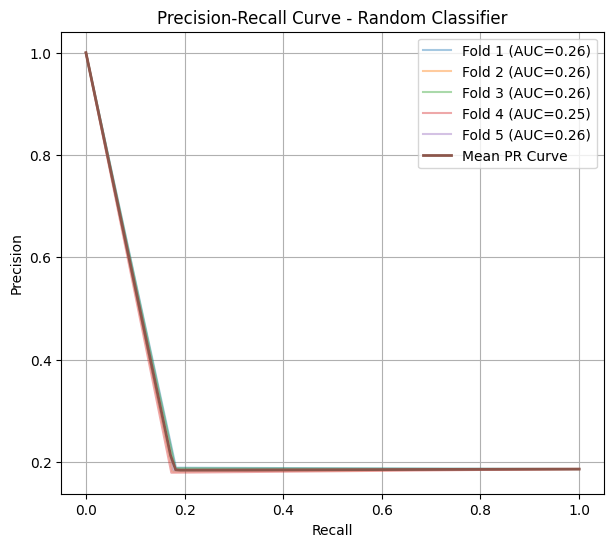

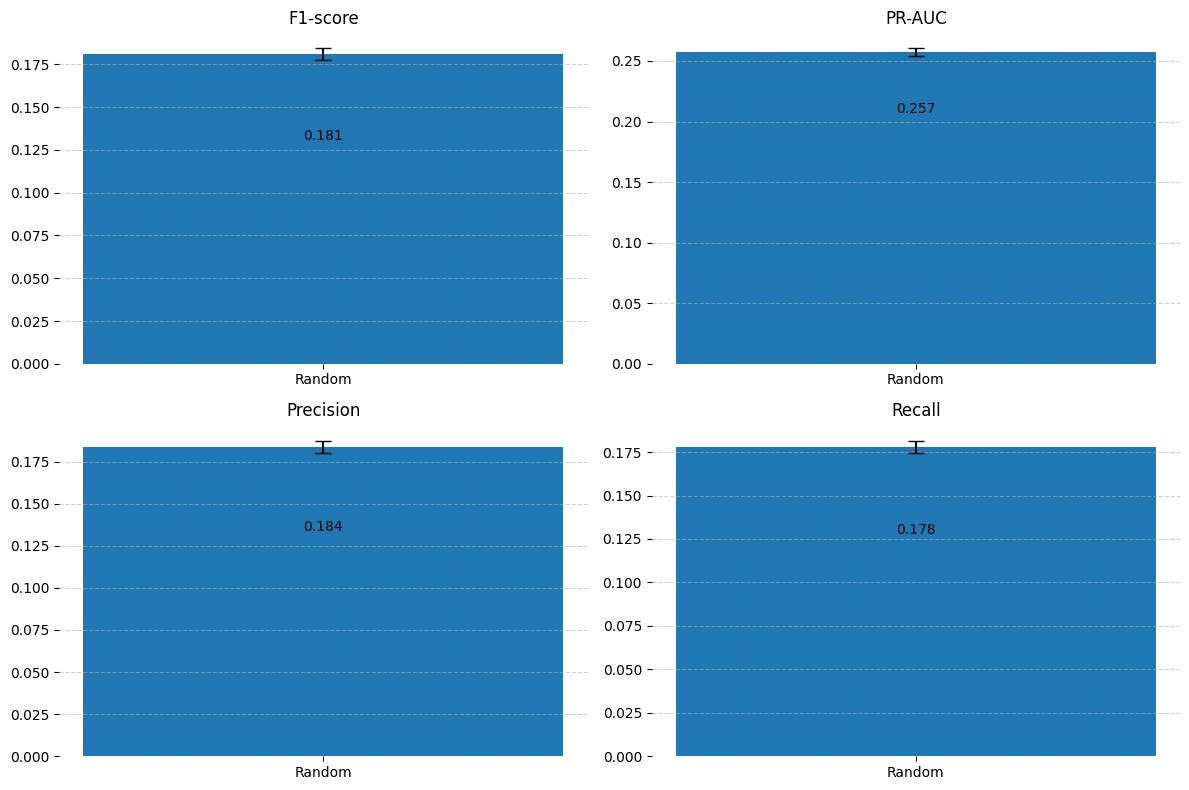

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, precision_recall_curve, auc, precision_score, recall_score

from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer

# -----------------------------
# Define target and input
# -----------------------------
X = df_clean.drop('boycott', axis=1)
y = df_clean['boycott'].astype(int)

# -----------------------------
# Random Classifier CV
# -----------------------------
def random_classifier_cv(X, y):

    random_state = 42
    outer_splits = 5

    # Detect column types
    numerical_cols = X.select_dtypes(include=['float64']).columns
    categorical_cols = X.select_dtypes(include=['object']).columns

    # Preprocessor
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('imputer', IterativeImputer(random_state=42, max_iter=10, sample_posterior=True)),
                ('scaler', StandardScaler())
            ]), numerical_cols),
            ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
        ]
    )

    # -----------------------------
    # RANDOM CLASSIFIER (FIXED)
    # -----------------------------
    model = DummyClassifier(
        strategy="stratified",   # ✅ FIXED (important)
        random_state=random_state
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    outer_cv = StratifiedKFold(n_splits=outer_splits, shuffle=True, random_state=random_state)

    # Storage
    outer_f1 = []
    outer_pr_auc = []
    outer_precision = []
    outer_recall = []
    outer_precisions = []
    outer_recalls = []

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), 1):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        pipeline.fit(X_train, y_train)

        y_pred = pipeline.predict(X_test)
        y_prob = pipeline.predict_proba(X_test)[:,1]

        outer_f1.append(f1_score(y_test, y_pred))
        outer_precision.append(precision_score(y_test, y_pred, zero_division=0))  # safer
        outer_recall.append(recall_score(y_test, y_pred))

        precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
        pr_auc = auc(recall_vals, precision_vals)
        outer_pr_auc.append(pr_auc)
        outer_precisions.append(precision_vals)
        outer_recalls.append(recall_vals)

    # -----------------------------
    # Print summary
    # -----------------------------
    print("\nRandom Classifier (baseline - stratified)")
    print(f"F1: {np.mean(outer_f1):.3f} ± {np.std(outer_f1):.3f}")
    print(f"PR-AUC: {np.mean(outer_pr_auc):.3f} ± {np.std(outer_pr_auc):.3f}")
    print(f"Precision: {np.mean(outer_precision):.3f} ± {np.std(outer_precision):.3f}")
    print(f"Recall: {np.mean(outer_recall):.3f} ± {np.std(outer_recall):.3f}")

    # -----------------------------
    # Plot PR curve
    # -----------------------------
    plt.figure(figsize=(7,6))
    for i in range(len(outer_precisions)):
        plt.plot(outer_recalls[i], outer_precisions[i], alpha=0.4,
                 label=f'Fold {i+1} (AUC={outer_pr_auc[i]:.2f})')

    mean_recall = np.linspace(0,1,100)
    interp_precs = [np.interp(mean_recall, r[::-1], p[::-1]) for p,r in zip(outer_precisions, outer_recalls)]
    mean_precision = np.mean(interp_precs, axis=0)
    plt.plot(mean_recall, mean_precision, linewidth=2, label='Mean PR Curve')

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve - Random Classifier")
    plt.legend()
    plt.grid(True)
    plt.show()

    # -----------------------------
    # Bar chart
    # -----------------------------
    metrics = {
        "F1-score": outer_f1,
        "PR-AUC": outer_pr_auc,
        "Precision": outer_precision,
        "Recall": outer_recall
    }

    fig, axes = plt.subplots(2,2, figsize=(12,8))
    axes = axes.flatten()

    for ax, (metric_name, values) in zip(axes, metrics.items()):
        mean_val = np.mean(values)
        std_val = np.std(values)

        ax.bar(["Random"], [mean_val], yerr=[std_val], capsize=6)
        ax.set_title(metric_name)
        ax.grid(axis='y', linestyle='--', alpha=0.6)

        ax.text(0, mean_val-0.05, f"{mean_val:.3f}", ha='center')

        for spine in ax.spines.values():
            spine.set_visible(False)

    plt.tight_layout()
    plt.show()


# -----------------------------
# RUN
# -----------------------------
random_classifier_cv(X, y)

## Random Forest

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_recall_curve, auc, precision_score, recall_score

from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer

X = df_clean.drop('boycott', axis=1)
y = df_clean['boycott'].astype(int)

def rf_nested_cv(X, y, use_class_weight=False):

    random_state = 42
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    numerical_cols = X.select_dtypes(include=['float64']).columns
    categorical_cols = X.select_dtypes(include=['object']).columns

    preprocessor = ColumnTransformer([
        ('num', Pipeline([
            ('imputer', IterativeImputer(random_state=42)),
            ('scaler', StandardScaler())
        ]), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ])

    model = RandomForestClassifier(
        random_state=random_state,
        class_weight='balanced' if use_class_weight else None
    )

    param_grid = {
        "model__n_estimators": [100, 200],
        "model__max_depth": [None, 5, 10],
        "model__min_samples_split": [2, 5]
    }

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    outer_f1, outer_pr_auc, outer_precision, outer_recall = [], [], [], []

    # ✅ NEW: store predictions
    all_y_true = []
    all_y_pred = []

    for train_idx, test_idx in outer_cv.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        grid = GridSearchCV(pipeline, param_grid, cv=inner_cv, scoring='f1')
        grid.fit(X_train, y_train)

        best_model = grid.best_estimator_

        y_pred = best_model.predict(X_test)
        y_prob = best_model.predict_proba(X_test)[:,1]

        # ✅ NEW: store results
        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)

        outer_f1.append(f1_score(y_test, y_pred))
        outer_precision.append(precision_score(y_test, y_pred, zero_division=0))
        outer_recall.append(recall_score(y_test, y_pred))

        p, r, _ = precision_recall_curve(y_test, y_prob)
        outer_pr_auc.append(auc(r, p))


    print(f"\nRandom Forest {'with' if use_class_weight else 'without'} weighting")
    print(f"F1: {np.mean(outer_f1):.3f} ± {np.std(outer_f1):.3f}")
    print(f"PR-AUC: {np.mean(outer_pr_auc):.3f} ± {np.std(outer_pr_auc):.3f}")
    print(f"Precision: {np.mean(outer_precision):.3f} ± {np.std(outer_precision):.3f}")
    print(f"Recall: {np.mean(outer_recall):.3f} ± {np.std(outer_recall):.3f}")

    # ✅ RETURN for confusion matrix
    return np.array(all_y_true), np.array(all_y_pred)


# -----------------------------
# RUN
# -----------------------------
y_true_rf, y_pred_rf = rf_nested_cv(X, y, use_class_weight=False)
y_true_rf_w, y_pred_rf_w = rf_nested_cv(X, y, use_class_weight=True)


Random Forest without weighting
F1: 0.285
PR-AUC: 0.486
Precision: 0.670
Recall: 0.181

Random Forest with weighting
F1: 0.476
PR-AUC: 0.473
Precision: 0.382
Recall: 0.631


In [47]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48020 entries, 0 to 50115
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          48020 non-null  object 
 1   news             48020 non-null  float64
 2   internet         47977 non-null  float64
 3   boycott          48020 non-null  object 
 4   gender           48020 non-null  object 
 5   age              47701 non-null  float64
 6   education_years  47292 non-null  float64
 7   ipcrtiva         47703 non-null  float64
 8   impricha         47787 non-null  float64
 9   ipeqopta         47739 non-null  float64
 10  ipshabta         47728 non-null  float64
 11  impsafea         47829 non-null  float64
 12  impdiffa         47762 non-null  float64
 13  ipfrulea         47453 non-null  float64
 14  ipudrsta         47670 non-null  float64
 15  ipmodsta         47745 non-null  float64
 16  ipgdtima         47789 non-null  float64
 17  impfreea         

In [50]:
df_clean.describe()

,news,internet,age,education_years,ipcrtiva,impricha,ipeqopta,ipshabta,impsafea,impdiffa,...,iphlppla,ipsucesa,ipstrgva,ipadvnta,ipbhprpa,iprspota,iplylfra,impenva,imptrada,impfuna
count,48020.000000,47977.000000,47701.000000,47292.000000,47703.000000,47787.000000,47739.000000,47728.000000,47829.000000,47762.000000,...,47819.000000,47681.000000,47466.000000,47749.000000,47679.000000,47613.000000,47802.000000,47786.000000,47771.000000,47763.000000
mean,88.078176,4.209455,51.638917,13.269644,2.617907,4.076046,2.043801,3.225318,2.256539,3.035886,...,2.190405,3.168579,2.243142,3.813064,2.633717,3.168609,1.968307,2.171117,2.709405,2.957038
std,127.151362,1.413080,18.604767,4.021168,1.289672,1.359482,1.072544,1.411892,1.194954,1.366847,...,1.020425,1.378260,1.166484,1.456293,1.248895,1.386924,0.977723,1.057693,1.364737,1.331004
min,0.000000,1.000000,15.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,30.000000,4.000000,37.000000,11.000000,2.000000,3.000000,1.000000,2.000000,1.000000,2.000000,...,1.000000,2.000000,1.000000,3.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000
50%,60.000000,5.000000,52.000000,13.000000,2.000000,4.000000,2.000000,3.000000,2.000000,3.000000,...,2.000000,3.000000,2.000000,4.000000,2.000000,3.000000,2.000000,2.000000,2.000000,3.000000
75%,105.000000,5.000000,67.000000,16.000000,3.000000,5.000000,3.000000,4.000000,3.000000,4.000000,...,3.000000,4.000000,3.000000,5.000000,3.000000,4.000000,2.000000,3.000000,4.000000,4.000000
max,941.000000,5.000000,90.000000,69.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,...,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000


# ALL using simpler

In [28]:
pip install lightgbm xgboost catboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [45]:
import numpy as np
np.random.seed(42)

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import f1_score, precision_recall_curve, auc, precision_score, recall_score
from sklearn.impute import SimpleImputer

# -----------------------------
# Data
# -----------------------------
X = df_clean.drop('boycott', axis=1)
y = df_clean['boycott'].astype(int)

numerical_cols = X.select_dtypes(include=['float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

# -----------------------------
# Preprocessor
# -----------------------------
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numerical_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

# -----------------------------
# Param grids (FULL, NOT REDUCED)
# -----------------------------
param_grids = {

    "Logistic Regression": {
        "C": [0.1, 1.0, 10.0]   # default = 1.0
    },

    "Random Forest": {
        "n_estimators": [50, 100, 200],   # default = 100
        "max_depth": [None, 5, 10]        # default = None
    },

    "Gradient Boosting": {
        "n_estimators": [50, 100, 200],   # default = 100
        "learning_rate": [0.05, 0.1, 0.2] # default = 0.1
    },

    "XGBoost": {
        "n_estimators": [50, 100, 200],   # default = 100
        "max_depth": [3, 6, 10],          # default = 6
        "learning_rate": [0.1, 0.3, 0.5] # default = 0.3
    },

    "LightGBM": {
        "n_estimators": [50, 100, 200],   # default = 100
        "num_leaves": [20, 31, 50],       # default = 31
        "learning_rate": [0.05, 0.1, 0.2] # default = 0.1
    },

    "CatBoost": {
        "iterations": [100, 200],         # reduced from 1000 for speed (acceptable)
        "depth": [4, 6, 8],               # default = 6
        "learning_rate": [0.01, 0.03, 0.1] # default = 0.03
    }
}

# -----------------------------
# Run models
# -----------------------------
def run_models(X, y, use_class_weight=False, threshold=0.5):

    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for name in param_grids.keys():

        print(f"\n{name} {'WITH' if use_class_weight else 'WITHOUT'} weighting")

        outer_f1, outer_pr_auc, outer_precision, outer_recall = [], [], [], []

        for train_idx, test_idx in outer_cv.split(X, y):

            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            # -----------------------------
            # Model per fold (IMPORTANT)
            # -----------------------------
            if name == "Logistic Regression":
                model = LogisticRegression(
                    max_iter=2000,
                    solver='liblinear',
                    class_weight='balanced' if use_class_weight else None
                )

            elif name == "Random Forest":
                model = RandomForestClassifier(
                    random_state=42,
                    class_weight='balanced' if use_class_weight else None
                )

            elif name == "Gradient Boosting":
                model = GradientBoostingClassifier(random_state=42)

            elif name == "XGBoost":
                if use_class_weight:
                    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
                    model = XGBClassifier(
                        eval_metric='logloss',
                        use_label_encoder=False,
                        scale_pos_weight=scale_pos_weight,
                        random_state=42
                    )
                else:
                    model = XGBClassifier(
                        eval_metric='logloss',
                        use_label_encoder=False,
                        random_state=42
                    )

            elif name == "LightGBM":
                model = LGBMClassifier(
                    class_weight='balanced' if use_class_weight else None,
                    random_state=42
                )

            elif name == "CatBoost":
                if use_class_weight:
                    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
                    model = CatBoostClassifier(
                        verbose=0,
                        class_weights=[1, scale_pos_weight],
                        random_state=42
                    )
                else:
                    model = CatBoostClassifier(
                        verbose=0,
                        random_state=42
                    )

            pipeline = Pipeline([
                ("preprocessor", preprocessor),
                ("model", model)
            ])

            param_grid = {f"model__{k}": v for k, v in param_grids[name].items()}

            grid = GridSearchCV(
                pipeline,
                param_grid=param_grid,
                cv=inner_cv,
                scoring='f1',
                n_jobs=-1
            )

            grid.fit(X_train, y_train)
            best_model = grid.best_estimator_

            # -----------------------------
            # Prediction (CONSISTENT)
            # -----------------------------
            y_prob = best_model.predict_proba(X_test)[:, 1]
            y_pred = (y_prob >= threshold).astype(int)

            outer_f1.append(f1_score(y_test, y_pred))
            outer_precision.append(precision_score(y_test, y_pred, zero_division=0))
            outer_recall.append(recall_score(y_test, y_pred))

            p, r, _ = precision_recall_curve(y_test, y_prob)
            outer_pr_auc.append(auc(r, p))

        print(f"F1: {np.mean(outer_f1):.3f} ± {np.std(outer_f1):.3f}")
        print(f"PR-AUC: {np.mean(outer_pr_auc):.3f} ± {np.std(outer_pr_auc):.3f}")
        print(f"Precision: {np.mean(outer_precision):.3f} ± {np.std(outer_precision):.3f}")
        print(f"Recall: {np.mean(outer_recall):.3f} ± {np.std(outer_recall):.3f}")


# -----------------------------
# RUN
# -----------------------------
run_models(X, y, use_class_weight=False)
run_models(X, y, use_class_weight=True)


Logistic Regression WITHOUT weighting
F1: 0.346 ± 0.025
PR-AUC: 0.480 ± 0.016
Precision: 0.639 ± 0.026
Recall: 0.238 ± 0.020

Random Forest WITHOUT weighting
F1: 0.299 ± 0.018
PR-AUC: 0.490 ± 0.013
Precision: 0.681 ± 0.020
Recall: 0.192 ± 0.014

Gradient Boosting WITHOUT weighting
F1: 0.373 ± 0.014
PR-AUC: 0.497 ± 0.014
Precision: 0.622 ± 0.020
Recall: 0.266 ± 0.012

XGBoost WITHOUT weighting


d:\Python\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
d:\Python\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
d:\Python\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
d:\Python\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
d:\Python\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
d:\Python\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_lab

F1: 0.395 ± 0.014
PR-AUC: 0.451 ± 0.014
Precision: 0.535 ± 0.017
Recall: 0.314 ± 0.017

LightGBM WITHOUT weighting


d:\Python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


F1: 0.396 ± 0.015
PR-AUC: 0.480 ± 0.010
Precision: 0.588 ± 0.010
Recall: 0.299 ± 0.015

CatBoost WITHOUT weighting
F1: 0.371 ± 0.013
PR-AUC: 0.501 ± 0.013
Precision: 0.645 ± 0.014
Recall: 0.261 ± 0.012

Logistic Regression WITH weighting
F1: 0.477 ± 0.005
PR-AUC: 0.476 ± 0.016
Precision: 0.363 ± 0.004
Recall: 0.695 ± 0.013

Random Forest WITH weighting
F1: 0.475 ± 0.005
PR-AUC: 0.474 ± 0.017
Precision: 0.382 ± 0.006
Recall: 0.627 ± 0.010

Gradient Boosting WITH weighting
F1: 0.373 ± 0.014
PR-AUC: 0.497 ± 0.014
Precision: 0.622 ± 0.020
Recall: 0.266 ± 0.012

XGBoost WITH weighting


d:\Python\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
d:\Python\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
d:\Python\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
d:\Python\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
d:\Python\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
d:\Python\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_lab

F1: 0.499 ± 0.003
PR-AUC: 0.501 ± 0.016
Precision: 0.398 ± 0.003
Recall: 0.669 ± 0.011

LightGBM WITH weighting


d:\Python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


F1: 0.498 ± 0.005
PR-AUC: 0.498 ± 0.015
Precision: 0.399 ± 0.001
Recall: 0.662 ± 0.018

CatBoost WITH weighting
F1: 0.499 ± 0.004
PR-AUC: 0.499 ± 0.013
Precision: 0.405 ± 0.003
Recall: 0.649 ± 0.014


## Tree vs non-tree

In [52]:
import numpy as np
np.random.seed(42)

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import f1_score, precision_recall_curve, auc, precision_score, recall_score
from sklearn.impute import SimpleImputer

# -----------------------------
# Data
# -----------------------------
X = df_clean.drop('boycott', axis=1)
y = df_clean['boycott'].astype(int)

numerical_cols = X.select_dtypes(include=['float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

# -----------------------------
# Preprocessors
# -----------------------------

# Non-tree (needs scaling)
preprocessor_non_tree = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numerical_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

# Tree (no scaling)
preprocessor_tree = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), numerical_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

# -----------------------------
# Param grids
# -----------------------------
param_grids = {
    "Logistic Regression": {"C": [0.1, 1.0, 10.0]},
    "Random Forest": {"n_estimators": [50, 100, 200], "max_depth": [None, 5, 10]},
    "Gradient Boosting": {"n_estimators": [50, 100, 200], "learning_rate": [0.05, 0.1, 0.2]},
    "XGBoost": {"n_estimators": [50, 100, 200], "max_depth": [3, 6, 10], "learning_rate": [0.1, 0.3, 0.5]},
    "LightGBM": {"n_estimators": [50, 100, 200], "num_leaves": [20, 31, 50], "learning_rate": [0.05, 0.1, 0.2]},
    "CatBoost": {"iterations": [100, 200], "depth": [4, 6, 8], "learning_rate": [0.01, 0.03, 0.1]}
}

# -----------------------------
# Run models
# -----------------------------
def run_models(X, y, use_class_weight=False, threshold=0.5):

    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for name in param_grids.keys():

        print(f"\n{name} {'WITH' if use_class_weight else 'WITHOUT'} weighting")

        outer_f1, outer_pr_auc, outer_precision, outer_recall = [], [], [], []

        for train_idx, test_idx in outer_cv.split(X, y):

            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            # -----------------------------
            # Select model
            # -----------------------------
            if name == "Logistic Regression":
                model = LogisticRegression(
                    max_iter=2000,
                    solver='liblinear',
                    class_weight='balanced' if use_class_weight else None
                )
                preprocessor = preprocessor_non_tree

            elif name == "Random Forest":
                model = RandomForestClassifier(
                    random_state=42,
                    class_weight='balanced' if use_class_weight else None
                )
                preprocessor = preprocessor_tree

            elif name == "Gradient Boosting":
                model = GradientBoostingClassifier(random_state=42)
                preprocessor = preprocessor_tree

            elif name == "XGBoost":
                scale = (y_train == 0).sum() / (y_train == 1).sum() if use_class_weight else 1
                model = XGBClassifier(
                    eval_metric='logloss',
                    use_label_encoder=False,
                    scale_pos_weight=scale,
                    random_state=42
                )
                preprocessor = preprocessor_tree

            elif name == "LightGBM":
                model = LGBMClassifier(
                    class_weight='balanced' if use_class_weight else None,
                    random_state=42
                )
                preprocessor = preprocessor_tree

            elif name == "CatBoost":
                scale = (y_train == 0).sum() / (y_train == 1).sum()
                model = CatBoostClassifier(
                    verbose=0,
                    random_state=42,
                    class_weights=[1, scale] if use_class_weight else None
                )
                preprocessor = preprocessor_tree  # still one-hot version

            pipeline = Pipeline([
                ("preprocessor", preprocessor),
                ("model", model)
            ])

            param_grid = {f"model__{k}": v for k, v in param_grids[name].items()}

            grid = GridSearchCV(
                pipeline,
                param_grid=param_grid,
                cv=inner_cv,
                scoring='f1',
                n_jobs=-1
            )

            grid.fit(X_train, y_train)
            best_model = grid.best_estimator_

            y_prob = best_model.predict_proba(X_test)[:, 1]
            y_pred = (y_prob >= threshold).astype(int)

            outer_f1.append(f1_score(y_test, y_pred))
            outer_precision.append(precision_score(y_test, y_pred, zero_division=0))
            outer_recall.append(recall_score(y_test, y_pred))

            p, r, _ = precision_recall_curve(y_test, y_prob)
            outer_pr_auc.append(auc(r, p))

        print(f"F1: {np.mean(outer_f1):.3f} ± {np.std(outer_f1):.3f}")
        print(f"PR-AUC: {np.mean(outer_pr_auc):.3f} ± {np.std(outer_pr_auc):.3f}")
        print(f"Precision: {np.mean(outer_precision):.3f} ± {np.std(outer_precision):.3f}")
        print(f"Recall: {np.mean(outer_recall):.3f} ± {np.std(outer_recall):.3f}")


# -----------------------------
# RUN
# -----------------------------
run_models(X, y, use_class_weight=False)
run_models(X, y, use_class_weight=True)


Logistic Regression WITHOUT weighting
F1: 0.346 ± 0.025
PR-AUC: 0.480 ± 0.016
Precision: 0.639 ± 0.026
Recall: 0.238 ± 0.020

Random Forest WITHOUT weighting
F1: 0.299 ± 0.017
PR-AUC: 0.490 ± 0.014
Precision: 0.680 ± 0.022
Recall: 0.191 ± 0.013

Gradient Boosting WITHOUT weighting
F1: 0.373 ± 0.014
PR-AUC: 0.497 ± 0.015
Precision: 0.622 ± 0.020
Recall: 0.266 ± 0.012

XGBoost WITHOUT weighting


d:\Python\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
d:\Python\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
d:\Python\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
d:\Python\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
d:\Python\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
d:\Python\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_lab

F1: 0.396 ± 0.014
PR-AUC: 0.451 ± 0.013
Precision: 0.535 ± 0.017
Recall: 0.314 ± 0.017

LightGBM WITHOUT weighting


d:\Python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


F1: 0.391 ± 0.008
PR-AUC: 0.480 ± 0.008
Precision: 0.587 ± 0.008
Recall: 0.293 ± 0.010

CatBoost WITHOUT weighting
F1: 0.371 ± 0.013
PR-AUC: 0.501 ± 0.013
Precision: 0.645 ± 0.014
Recall: 0.261 ± 0.012

Logistic Regression WITH weighting
F1: 0.477 ± 0.005
PR-AUC: 0.476 ± 0.016
Precision: 0.363 ± 0.004
Recall: 0.695 ± 0.013

Random Forest WITH weighting
F1: 0.475 ± 0.005
PR-AUC: 0.474 ± 0.017
Precision: 0.383 ± 0.006
Recall: 0.627 ± 0.011

Gradient Boosting WITH weighting
F1: 0.373 ± 0.014
PR-AUC: 0.497 ± 0.015
Precision: 0.622 ± 0.020
Recall: 0.266 ± 0.012

XGBoost WITH weighting


d:\Python\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
d:\Python\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
d:\Python\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
d:\Python\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
d:\Python\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
d:\Python\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_lab

F1: 0.499 ± 0.003
PR-AUC: 0.501 ± 0.016
Precision: 0.398 ± 0.003
Recall: 0.669 ± 0.011

LightGBM WITH weighting


d:\Python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


F1: 0.496 ± 0.005
PR-AUC: 0.500 ± 0.018
Precision: 0.393 ± 0.005
Recall: 0.673 ± 0.025

CatBoost WITH weighting
F1: 0.499 ± 0.004
PR-AUC: 0.499 ± 0.013
Precision: 0.405 ± 0.003
Recall: 0.649 ± 0.014


In [ ]:
import numpy as np
np.random.seed(42)

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import f1_score, precision_recall_curve, auc, precision_score, recall_score

from catboost import CatBoostClassifier
from sklearn.impute import SimpleImputer

# -----------------------------
# Data
# -----------------------------
X = df_clean.drop('boycott', axis=1)
y = df_clean['boycott'].astype(int)

# Identify columns
numerical_cols = X.select_dtypes(include=['float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

# Convert categorical columns to string (IMPORTANT for CatBoost)
X[categorical_cols] = X[categorical_cols].astype(str)

# Get categorical indices
cat_features = [X.columns.get_loc(col) for col in categorical_cols]

# -----------------------------
# Simple imputation (no scaling, no encoding)
# -----------------------------
imputer = SimpleImputer(strategy='median')
X[numerical_cols] = imputer.fit_transform(X[numerical_cols])

# -----------------------------
# Param grid
# -----------------------------
param_grid = {
    "iterations": [100, 200],
    "depth": [4, 6, 8],
    "learning_rate": [0.01, 0.03, 0.1]
}

# -----------------------------
# Run CatBoost
# -----------------------------
def run_catboost(X, y, use_class_weight=False, threshold=0.5):

    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    print(f"\nCatBoost (NATIVE) {'WITH' if use_class_weight else 'WITHOUT'} weighting")

    outer_f1, outer_pr_auc, outer_precision, outer_recall = [], [], [], []

    for train_idx, test_idx in outer_cv.split(X, y):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # weighting
        if use_class_weight:
            n_neg = (y_train == 0).sum()
            n_pos = (y_train == 1).sum()
            class_weights = [1, n_neg / n_pos]
        else:
            class_weights = None

        model = CatBoostClassifier(
            verbose=0,
            random_state=42,
            class_weights=class_weights
        )

        grid = GridSearchCV(
            model,
            param_grid=param_grid,
            cv=inner_cv,
            scoring='f1',
            n_jobs=-1
        )

        grid.fit(
            X_train,
            y_train,
            cat_features=cat_features   # 🔥 KEY LINE
        )

        best_model = grid.best_estimator_

        y_prob = best_model.predict_proba(X_test)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)

        outer_f1.append(f1_score(y_test, y_pred))
        outer_precision.append(precision_score(y_test, y_pred, zero_division=0))
        outer_recall.append(recall_score(y_test, y_pred))

        p, r, _ = precision_recall_curve(y_test, y_prob)
        outer_pr_auc.append(auc(r, p))

    print(f"F1: {np.mean(outer_f1):.3f} ± {np.std(outer_f1):.3f}")
    print(f"PR-AUC: {np.mean(outer_pr_auc):.3f} ± {np.std(outer_pr_auc):.3f}")
    print(f"Precision: {np.mean(outer_precision):.3f} ± {np.std(outer_precision):.3f}")
    print(f"Recall: {np.mean(outer_recall):.3f} ± {np.std(outer_recall):.3f}")


# -----------------------------
# RUN
# -----------------------------
run_catboost(X, y, use_class_weight=False)
run_catboost(X, y, use_class_weight=True)


CatBoost (NATIVE) WITHOUT weighting
F1: 0.375 ± 0.019
PR-AUC: 0.502 ± 0.015
Precision: 0.631 ± 0.019
Recall: 0.267 ± 0.016

CatBoost (NATIVE) WITH weighting
F1: 0.500 ± 0.004
PR-AUC: 0.502 ± 0.012
Precision: 0.404 ± 0.007
Recall: 0.654 ± 0.017


In [63]:
import numpy as np
np.random.seed(42)

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    f1_score, precision_recall_curve, auc,
    precision_score, recall_score, confusion_matrix
)

from catboost import CatBoostClassifier
from sklearn.impute import SimpleImputer

# -----------------------------
# Data
# -----------------------------
X = df_clean.drop('boycott', axis=1)
y = df_clean['boycott'].astype(int)

numerical_cols = X.select_dtypes(include=['float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

X[categorical_cols] = X[categorical_cols].astype(str)
cat_features = [X.columns.get_loc(col) for col in categorical_cols]

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# -----------------------------
# Imputation
# -----------------------------
imputer = SimpleImputer(strategy='median')
X_train[numerical_cols] = imputer.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = imputer.transform(X_test[numerical_cols])

# -----------------------------
# Param grid (UNCHANGED)
# -----------------------------
param_grid = {
    "iterations": [100, 200],
    "depth": [4, 6, 8],
    "learning_rate": [0.01, 0.03, 0.1]
}

# -----------------------------
# CV setup
# -----------------------------
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------------
# Function
# -----------------------------
def run_catboost_full(X_train, y_train, X_test, y_test, use_class_weight=False, threshold=0.5):

    print(f"\nCatBoost {'WITH' if use_class_weight else 'WITHOUT'} weighting")

    # class weights
    if use_class_weight:
        n_neg = (y_train == 0).sum()
        n_pos = (y_train == 1).sum()
        class_weights = [1, n_neg / n_pos]
    else:
        class_weights = None

    outer_f1, outer_pr_auc, outer_precision, outer_recall = [], [], [], []

    # -----------------------------
    # 1. CV on TRAIN (mean ± std)
    # -----------------------------
    for train_idx, val_idx in outer_cv.split(X_train, y_train):

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = CatBoostClassifier(
            verbose=0,
            random_state=42,
            class_weights=class_weights
        )

        grid = GridSearchCV(
            model,
            param_grid=param_grid,
            cv=inner_cv,
            scoring='f1',
            n_jobs=-1
        )

        grid.fit(X_tr, y_tr, cat_features=cat_features)
        best_model = grid.best_estimator_

        y_prob = best_model.predict_proba(X_val)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)

        outer_f1.append(f1_score(y_val, y_pred))
        outer_precision.append(precision_score(y_val, y_pred, zero_division=0))
        outer_recall.append(recall_score(y_val, y_pred))

        p, r, _ = precision_recall_curve(y_val, y_prob)
        outer_pr_auc.append(auc(r, p))

    print("\n--- CV (Train 80%) ---")
    print(f"F1: {np.mean(outer_f1):.3f} ± {np.std(outer_f1):.3f}")
    print(f"PR-AUC: {np.mean(outer_pr_auc):.3f} ± {np.std(outer_pr_auc):.3f}")
    print(f"Precision: {np.mean(outer_precision):.3f} ± {np.std(outer_precision):.3f}")
    print(f"Recall: {np.mean(outer_recall):.3f} ± {np.std(outer_recall):.3f}")

    # -----------------------------
    # 2. Train final model on FULL 80%
    # -----------------------------
    final_model = CatBoostClassifier(
        verbose=0,
        random_state=42,
        class_weights=class_weights
    )

    final_grid = GridSearchCV(
        final_model,
        param_grid=param_grid,
        cv=inner_cv,
        scoring='f1',
        n_jobs=-1
    )

    final_grid.fit(X_train, y_train, cat_features=cat_features)
    best_final_model = final_grid.best_estimator_

    # -----------------------------
    # 3. Evaluate on HOLDOUT (20%)
    # -----------------------------
    y_prob = best_final_model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred)

    p, r, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(r, p)

    print("\n--- HOLDOUT (20%) ---")
    print(f"F1: {f1:.3f}")
    print(f"PR-AUC: {pr_auc:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")

    # -----------------------------
    # 4. Confusion Matrix
    # -----------------------------
    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix:")
    print(cm)

In [64]:
run_catboost_full(X_train, y_train, X_test, y_test, use_class_weight=False)
run_catboost_full(X_train, y_train, X_test, y_test, use_class_weight=True)


CatBoost WITHOUT weighting

--- CV (Train 80%) ---
F1: 0.380 ± 0.007
PR-AUC: 0.497 ± 0.006
Precision: 0.637 ± 0.014
Recall: 0.271 ± 0.007

--- HOLDOUT (20%) ---
F1: 0.387
PR-AUC: 0.501
Precision: 0.625
Recall: 0.280

Confusion Matrix:
[[7519  300]
 [1285  500]]

CatBoost WITH weighting

--- CV (Train 80%) ---
F1: 0.502 ± 0.012
PR-AUC: 0.498 ± 0.010
Precision: 0.413 ± 0.012
Recall: 0.641 ± 0.011

--- HOLDOUT (20%) ---
F1: 0.500
PR-AUC: 0.511
Precision: 0.404
Recall: 0.658

Confusion Matrix:
[[6083 1736]
 [ 610 1175]]
